# Phase 2b — Transfer Learning Comparison (ResNet18 vs. Baseline CNN)

Fine-tunes an ImageNet-pretrained ResNet18 on NEU-DET and compares it
against the `BaselineCNN` results from `02_baseline_model.ipynb`
(val_acc=90.28%, val_loss=0.2616, weighted F1=0.90).

Reuses the same `fit()` / `evaluate()` training loop — only the model
and the input transform change.

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

%matplotlib inline

from src.data.dataset import NEUDataset, CLASS_NAMES
from src.models.transfer_model import build_resnet18, resnet_transform
from src.models.train import fit, evaluate

DATA_ROOT = '../data/raw/NEU-DET'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## Data — note the `transform=resnet_transform`

Converts the grayscale (1, H, W) images to ImageNet-normalized (3, H, W)
tensors, required for a pretrained ResNet.

In [2]:
train_set = NEUDataset(f'{DATA_ROOT}/train', transform=resnet_transform)
val_set = NEUDataset(f'{DATA_ROOT}/validation', transform=resnet_transform)
print(f'Train samples: {len(train_set)} | Val samples: {len(val_set)}')

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

Train samples: 1440 | Val samples: 360


## Fine-tune ResNet18 (full fine-tuning, not just the last layer)

Uses a lower learning rate than the baseline (1e-4 vs 1e-3) since we're
adjusting already-good pretrained weights, not learning from scratch.

In [3]:
resnet_model = build_resnet18(num_classes=len(CLASS_NAMES), freeze_backbone=False).to(device)

resnet_history = fit(
    resnet_model,
    train_loader,
    val_loader,
    device,
    epochs=10,          # ResNet converges faster than the baseline thanks to pretraining
    lr=1e-4,
    checkpoint_path='../models/resnet18_finetuned.pt',
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\NoteBook/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.60MB/s]


Epoch  1/10 | train_loss=0.2262 train_acc=0.9361 | val_loss=0.0881 val_acc=0.9667
  -> saved new best checkpoint (val_acc=0.9667)


Epoch  2/10 | train_loss=0.0149 train_acc=0.9979 | val_loss=0.0075 val_acc=1.0000
  -> saved new best checkpoint (val_acc=1.0000)


Epoch  3/10 | train_loss=0.0107 train_acc=0.9972 | val_loss=0.0091 val_acc=0.9972


...

Epoch  6/10 | train_loss=0.0151 train_acc=0.9958 | val_loss=0.0148 val_acc=0.9917


Epoch  7/10 | train_loss=0.0156 train_acc=0.9951 | val_loss=0.0022 val_acc=1.0000


Epoch  8/10 | train_loss=0.0231 train_acc=0.9958 | val_loss=0.0031 val_acc=1.0000


Epoch  9/10 | train_loss=0.0032 train_acc=1.0000 | val_loss=0.0011 val_acc=1.0000


Epoch 10/10 | train_loss=0.0199 train_acc=0.9944 | val_loss=0.0044 val_acc=1.0000


## Training curves

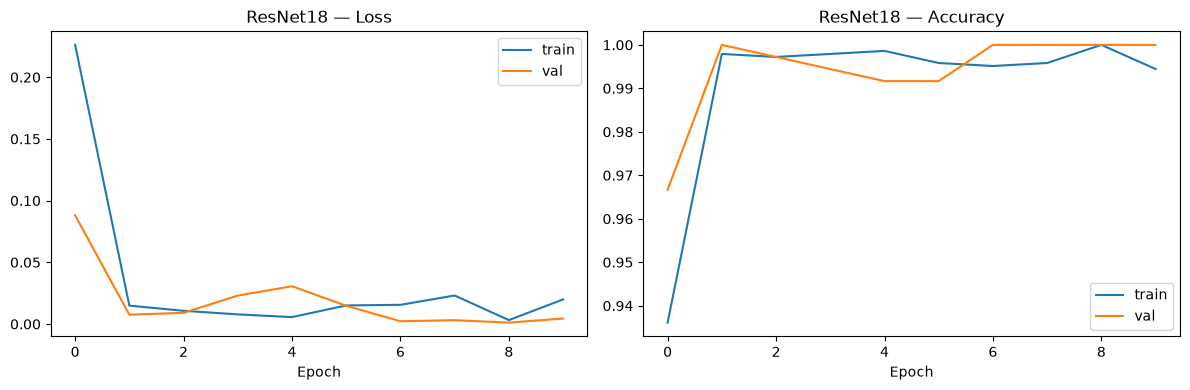

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(resnet_history['train_loss'], label='train')
axes[0].plot(resnet_history['val_loss'], label='val')
axes[0].set_title('ResNet18 — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(resnet_history['train_acc'], label='train')
axes[1].plot(resnet_history['val_acc'], label='val')
axes[1].set_title('ResNet18 — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## Final comparison: Baseline CNN vs. ResNet18

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# Load best ResNet18 checkpoint
resnet_model.load_state_dict(torch.load('../models/resnet18_finetuned.pt', map_location=device))
resnet_val_loss, resnet_val_acc, y_true, y_pred = evaluate(
    resnet_model, val_loader, nn.CrossEntropyLoss(), device
)

# Baseline numbers from 02_baseline_model.ipynb (hardcode from that run's output)
baseline_val_acc = 0.9028
baseline_val_loss = 0.2616

print(f"{'Model':<20}{'Val Accuracy':<15}{'Val Loss':<10}")
print(f"{'Baseline CNN':<20}{baseline_val_acc:<15.4f}{baseline_val_loss:<10.4f}")
print(f"{'ResNet18 (fine-tuned)':<20}{resnet_val_acc:<15.4f}{resnet_val_loss:<10.4f}")
print()
print('ResNet18 classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Model               Val Accuracy   Val Loss  
Baseline CNN        0.9028         0.2616    
ResNet18 (fine-tuned)1.0000         0.0075    

ResNet18 classification report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



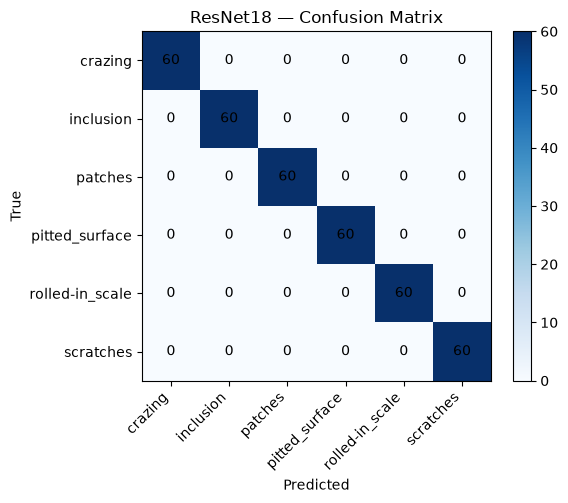

In [6]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('ResNet18 — Confusion Matrix')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im)
plt.tight_layout()
plt.show()